# Option B: 2023‑2025 Non‑WTCS Race Review

Filters: 2023‑01‑01 → 2025‑12‑31, excludes categories containing “World Championship Series”, retains DNFs, and highlights USA-focused metrics plus Sullivan bike-pack case studies.

**What you'll find:**
- dataset pull helper and cleanliness summary
- USA team-level averages + visuals (Option B view)
- event-level depth snapshot to spot good/bad stops
- bike pack co-occurrences with Sullivan Middaugh to flag cooperation case studies

In [18]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "tri_analysis").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

tri_analysis_path = PROJECT_ROOT / "tri_analysis"
if str(tri_analysis_path) not in sys.path:
    sys.path.append(str(tri_analysis_path))

from database import get_engine  # noqa: E402

sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 30)

In [19]:
START_DATE = "2023-01-01"
END_DATE = "2025-12-31"
WTCS_KEYWORD = "%World Championship Series%"
TARGET_SULLIVAN = "Sullivan Middaugh"  # swap to Ethan/Kerry if needed

engine = get_engine()

BASE_QUERY = """
SELECT
    rr.event_id,
    rr.prog_id,
    e.event_name,
    e.event_date,
    e.event_country,
    e.event_venue,
    e.cat_name,
    e.prog_name,
    e.prog_distance_category,
    rr.athlete_id,
    rr.athlete_full_name,
    rr.finish_status,
    rr.finish_position,
    rr.position_sort,
    rr.total_time,
    a.country AS athlete_country,
    a.gender,
    pm.position_at_swim,
    pm.position_at_bike,
    pm.position_at_run,
    pm.swimrank,
    pm.bikerank,
    pm.runrank,
    pm.elapsedswim,
    pm.elapsedbike,
    pm.elapsedrun,
    pm.behindswim,
    pm.behindbike
FROM race_results rr
JOIN events e
  ON rr.event_id = e.event_id
 AND rr.prog_id = e.prog_id
LEFT JOIN athlete a
  ON rr.athlete_id = a.athlete_id
LEFT JOIN position_metrics pm
  ON rr.event_id = pm.event_id
 AND rr.prog_id = pm.prog_id
 AND rr.athlete_id = pm.athlete_id
WHERE e.event_date BETWEEN %(start_date)s AND %(end_date)s
  AND (
        e.cat_name IS NULL
        OR e.cat_name NOT ILIKE %(wtcs_keyword)s
      )
ORDER BY e.event_date DESC, rr.position_sort ASC;
"""

params = {
    "start_date": START_DATE,
    "end_date": END_DATE,
    "wtcs_keyword": WTCS_KEYWORD,
}

df = pd.read_sql_query(
    BASE_QUERY,
    engine,
    params=params,
    parse_dates=["event_date"],
)

print(
    f"Loaded {len(df):,} rows from {df['event_id'].nunique()} events / "
    f"{df['prog_id'].nunique()} programs (Option B filter)."
)
df.head()

Loaded 26,012 rows from 365 events / 861 programs (Option B filter).


,event_id,prog_id,event_name,event_date,event_country,event_venue,cat_name,prog_name,prog_distance_category,athlete_id,athlete_full_name,finish_status,finish_position,position_sort,total_time,athlete_country,gender,position_at_swim,position_at_bike,position_at_run,swimrank,bikerank,runrank,elapsedswim,elapsedbike,elapsedrun,behindswim,behindbike
0,194875,673993,2025 Americas Triathlon Cup Manta,2025-11-23,Ecuador,Malecón de Playa Murciélago,Continental Cup,Elite Men,sprint,103258,Liam Donnelly,FINISH,1.0,1,00:51:44,Canada,male,17.0,1.0,1.0,17.0,17.0,1.0,554.0,2193.0,3107.0,10,0
1,194875,673994,2025 Americas Triathlon Cup Manta,2025-11-23,Ecuador,Malecón de Playa Murciélago,Continental Cup,Elite Women,sprint,195687,Faith Duncan,FINISH,1.0,1,00:59:02,United States,female,6.0,4.0,1.0,6.0,1.0,1.0,640.0,2464.0,3545.0,13,3
2,194875,673994,2025 Americas Triathlon Cup Manta,2025-11-23,Ecuador,Malecón de Playa Murciélago,Continental Cup,Elite Women,sprint,124609,Ana Maria Valentina Torres Gomez,FINISH,2.0,2,00:59:35,Mexico,female,1.0,4.0,2.0,1.0,5.0,2.0,627.0,2464.0,3578.0,0,3
3,194875,673993,2025 Americas Triathlon Cup Manta,2025-11-23,Ecuador,Malecón de Playa Murciélago,Continental Cup,Elite Men,sprint,124358,Erik Yamir Ramos Croda,FINISH,2.0,2,00:51:57,Mexico,male,21.0,1.0,2.0,21.0,11.0,3.0,557.0,2193.0,3121.0,13,0
4,194875,673993,2025 Americas Triathlon Cup Manta,2025-11-23,Ecuador,Malecón de Playa Murciélago,Continental Cup,Elite Men,sprint,12773,Rodrigo Gonzalez Lopez,FINISH,3.0,3,00:52:04,Mexico,male,12.0,11.0,3.0,12.0,24.0,2.0,551.0,2196.0,3127.0,7,3


In [16]:
df["finish_status_clean"] = df["finish_status"].fillna("UNKNOWN").str.upper()
numeric_cols = [
    "finish_position",
    "position_sort",
    "elapsedswim",
    "elapsedbike",
    "elapsedrun",
    "runrank",
    "bikerank",
    "behindswim",
    "behindbike",
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["usa_flag"] = df["athlete_country"].eq("United States")
df["is_dnf"] = df["finish_status_clean"] != "FINISH"
df["event_year"] = df["event_date"].dt.year
df["event_month"] = df["event_date"].dt.to_period("M").astype(str)

status_pivot = (
    df.groupby(["event_year", "finish_status_clean"])
      .size()
      .rename("athlete_starts")
      .reset_index()
      .pivot(index="event_year", columns="finish_status_clean", values="athlete_starts")
      .fillna(0)
      .astype(int)
)
status_pivot

finish_status_clean,DNF,DNS,DSQ,FINISH,LAP
event_year,,,,,
2023,629,53,48,7807,221
2024,595,58,38,7484,314
2025,566,79,27,7918,175


## USA team averages (Option B window)

Understanding baseline finish + DNF rates for USA athletes sets expectations before drilling into case studies.

In [17]:
usa_df = df[df["usa_flag"]].copy()
usa_yearly = (
    usa_df.groupby("event_year")
    .agg(
        athlete_starts=("athlete_id", "count"),
        unique_athletes=("athlete_id", "nunique"),
        avg_finish_position=("finish_position", "mean"),
        median_finish_position=("finish_position", "median"),
        dnf_rate=("is_dnf", "mean"),
    )
    .sort_index()
)

if usa_yearly.empty:
    print("No USA race starts for the selected filters.")
else:
    usa_yearly

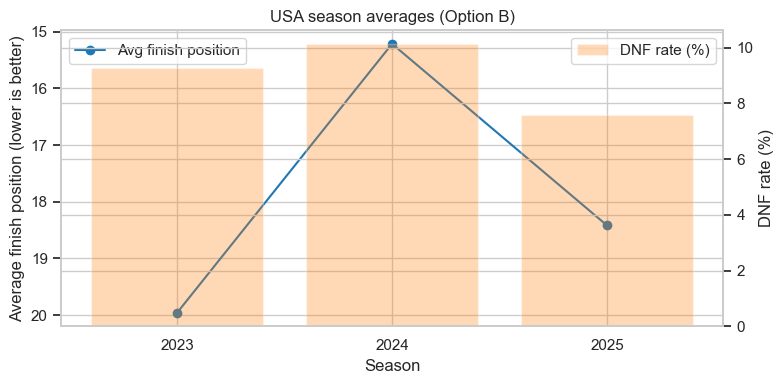

In [8]:
if usa_yearly.empty:
    print("USA trend chart skipped — no data in the Option B window.")
else:
    fig, ax1 = plt.subplots(figsize=(8, 4))
    years = usa_yearly.index.to_list()
    ax1.plot(
        years,
        usa_yearly["avg_finish_position"],
        marker="o",
        color="#1f77b4",
        label="Avg finish position",
    )
    ax1.set_ylabel("Average finish position (lower is better)")
    ax1.set_xlabel("Season")
    ax1.invert_yaxis()
    ax1.set_xticks(years)

    ax2 = ax1.twinx()
    ax2.bar(
        years,
        usa_yearly["dnf_rate"].fillna(0) * 100,
        alpha=0.3,
        color="#ff7f0e",
        label="DNF rate (%)",
    )
    ax2.set_ylabel("DNF rate (%)")

    ax1.set_title("USA season averages (Option B)")
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

In [23]:
usa_event_summary = (
    usa_df.groupby(["event_id", "prog_id", "event_name", "event_date", "event_country"])
    .agg(
        usa_starts=("athlete_id", "count"),
        usa_finish_avg=("finish_position", "mean"),
        usa_finish_median=("finish_position", "median"),
        usa_dnf_rate=("is_dnf", "mean"),
    )
    .reset_index()
    .sort_values("event_date", ascending=False)
)

if usa_event_summary.empty:
    print("No USA event summaries available for the Option B window.")
else:
    cols = [
        "event_date",
        "event_name",
        "event_country",
        "usa_starts",
        "usa_finish_avg",
        "usa_finish_median",
        "usa_dnf_rate",
    ]
    usa_event_summary[cols].head(12)

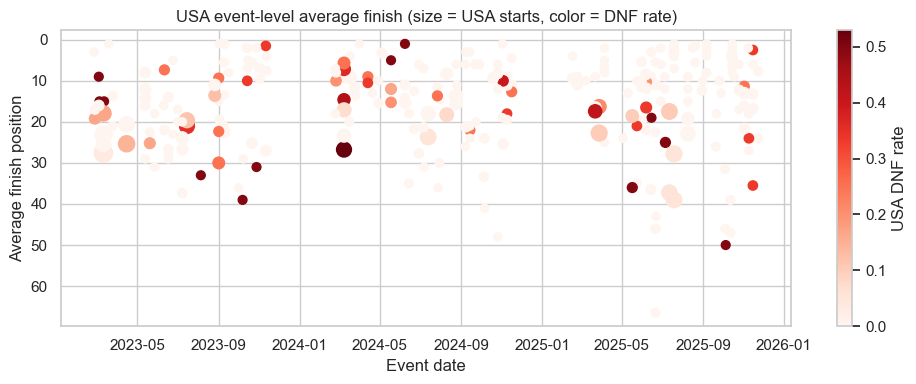

In [10]:
if usa_event_summary.empty:
    print("Event scatter skipped — no USA events in scope.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    scatter = ax.scatter(
        usa_event_summary["event_date"],
        usa_event_summary["usa_finish_avg"],
        c=usa_event_summary["usa_dnf_rate"].fillna(0),
        cmap="Reds",
        s=30 + usa_event_summary["usa_starts"] * 5,
    )
    ax.set_title("USA event-level average finish (size = USA starts, color = DNF rate)")
    ax.set_ylabel("Average finish position")
    ax.set_xlabel("Event date")
    ax.invert_yaxis()
    plt.colorbar(scatter, ax=ax, label="USA DNF rate")
    plt.tight_layout()
    plt.show()

## Sullivan swim + placement profile
We promised an option-b view that proves Sullivan’s bike strength *and* highlights his improving swim gap. The next cells zoom in on the target athlete only.

In [21]:
def seconds_to_mmss(value: float) -> str:
    if pd.isna(value):
        return "--"
    minutes, seconds = divmod(int(round(value)), 60)
    return f"{minutes:02d}:{seconds:02d}"

sullivan_df = (
    df[df["athlete_full_name"].eq(TARGET_SULLIVAN)]
    .copy()
    .sort_values("event_date")
)

if sullivan_df.empty:
    print(f"No records for {TARGET_SULLIVAN} within Option B filters.")
else:
    sullivan_df["swim_gap_seconds"] = sullivan_df["behindswim"]
    sullivan_df["bike_rank"] = sullivan_df["bikerank"]
    swim_avg = sullivan_df["swim_gap_seconds"].mean()
    swim_med = sullivan_df["swim_gap_seconds"].median()
    bike_rank_avg = sullivan_df["bike_rank"].mean()
    finish_avg = sullivan_df["finish_position"].mean()
    summary_df = pd.DataFrame(
        {
            "metric": [
                "Starts",
                "Avg swim gap",
                "Median swim gap",
                "Avg bike rank",
                "Avg finish position",
            ],
            "value": [
                len(sullivan_df),
                seconds_to_mmss(swim_avg),
                seconds_to_mmss(swim_med),
                round(bike_rank_avg, 1),
                round(finish_avg, 1),
            ],
        }
    )
    summary_df

In [22]:
if sullivan_df.empty:
    print("Swim gap trend skipped — no Sullivan rows.")
else:
    fig, ax1 = plt.subplots(figsize=(9, 4))
    ax1.plot(
        sullivan_df["event_date"],
        sullivan_df["swim_gap_seconds"] / 60,
        marker="o",
        color="#1f77b4",
        label="Swim gap (min)"
)
    ax1.set_ylabel("Swim gap (minutes)")
    ax1.set_xlabel("Event date")
    ax1.set_title(f"{TARGET_SULLIVAN}: Swim gap vs finish placement")
\n
    ax2 = ax1.twinx()
    ax2.plot(
        sullivan_df["event_date"],
        sullivan_df["finish_position"],
        marker="s",
        linestyle="--",
        color="#ff7f0e",
        label="Finish position"
)
    ax2.invert_yaxis()
    ax2.set_ylabel("Finish position")
\n
    handles, labels = [], []
    for ax in (ax1, ax2):
        h, lab = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(lab)
    ax1.legend(handles, labels, loc="upper right")
    plt.tight_layout()
    plt.show()

SyntaxError: unexpected character after line continuation character (3965383278.py, line 15)

In [ ]:
def classify_finish(row):
    if row["finish_status_clean"] != "FINISH":
        return "DNF/DNS"
    pos = row["finish_position"]
    if pd.isna(pos):
        return "Unknown"
    if pos <= 3:
        return "Podium"
    if pos <= 10:
        return "Top 10"
    if pos <= 20:
        return "Top 20"
    return "Finish 21+"
\n
if sullivan_df.empty:
    print("Placement distribution skipped — no Sullivan rows.")
else:
    sullivan_df["placement_bucket"] = sullivan_df.apply(classify_finish, axis=1)
    placement_summary = (
        sullivan_df.groupby("placement_bucket")
        .agg(
            starts=("event_id", "count"),
            avg_swim_gap=("swim_gap_seconds", "mean"),
            avg_bike_rank=("bike_rank", "mean"),
        )
        .sort_values("starts", ascending=False)
    )
    placement_summary["avg_swim_gap_mmss"] = placement_summary["avg_swim_gap"].apply(seconds_to_mmss)
    placement_summary["avg_bike_rank"] = placement_summary["avg_bike_rank"].round(1)
    placement_summary

In [ ]:
if sullivan_df.empty:
    print("Placement viz skipped — no Sullivan rows.")
else:
    order = ["Podium", "Top 10", "Top 20", "Finish 21+", "DNF/DNS", "Unknown"]
    plot_data = placement_summary.reindex(order).dropna(subset=["starts"])
    if plot_data.empty:
        print("No placement buckets to chart.")
    else:
        fig, ax1 = plt.subplots(figsize=(8, 3.5))
        ax1.bar(
            plot_data.index,
            plot_data["avg_swim_gap"] / 60,
            color="#6baed6",
            label="Avg swim gap (min)",
        )
        ax1.set_ylabel("Avg swim gap (minutes)")
        ax1.set_xticklabels(plot_data.index, rotation=20, ha="right")
\n
        ax2 = ax1.twinx()
        ax2.plot(
            plot_data.index,
            plot_data["avg_bike_rank"],
            color="#d62728",
            marker="o",
            label="Avg bike rank"
)
        ax2.invert_yaxis()
        ax2.set_ylabel("Avg bike rank")
\n
        handles, labels = [], []
        for ax in (ax1, ax2):
            h, lab = ax.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(lab)
        ax1.legend(handles, labels, loc="upper right")
        ax1.set_title(f"Swim gap vs bike rank by placement — {TARGET_SULLIVAN}")
        plt.tight_layout()
        plt.show()

In [24]:
def identify_packs(times, max_gap_to_leader=2, max_gap_within_pack=1):
    """Assign pack IDs based on elapsed times (NaN ⇒ -1)."""
    arr = np.asarray(times, dtype=float)
    pack_ids = np.full(arr.shape, -1, dtype=int)
    valid_indices = np.where(~np.isnan(arr))[0]
    if len(valid_indices) == 0:
        return pack_ids

    current_pack = 0
    i = 0
    while i < len(valid_indices):
        leader_idx = valid_indices[i]
        pack_ids[leader_idx] = current_pack
        leader_time = arr[leader_idx]
        j = i + 1
        while j < len(valid_indices):
            curr_idx = valid_indices[j]
            prev_idx = valid_indices[j - 1]
            gap_to_prev = arr[curr_idx] - arr[prev_idx]
            gap_to_leader = arr[curr_idx] - leader_time
            if (gap_to_prev <= max_gap_within_pack) or (gap_to_leader <= max_gap_to_leader):
                pack_ids[curr_idx] = current_pack
                j += 1
            else:
                break
        current_pack += 1
        i = j
    return pack_ids


def assign_bike_packs(results_df, max_gap_to_leader=2, max_gap_within_pack=1):
    enriched_frames = []
    for (_, _), group in results_df.groupby(["event_id", "prog_id"], group_keys=False):
        sorted_group = group.sort_values("elapsedbike", na_position="last").copy()
        packs = identify_packs(
            sorted_group["elapsedbike"].to_numpy(dtype=float),
            max_gap_to_leader,
            max_gap_within_pack,
        )
        sorted_group["bike_pack_id"] = packs
        enriched_frames.append(sorted_group)
    return (
        pd.concat(enriched_frames)
        .sort_values(["event_date", "position_sort"])
        .reset_index(drop=True)
    )


bike_enriched = assign_bike_packs(df)
bike_enriched[["event_name", "athlete_full_name", "elapsedbike", "bike_pack_id"]].head()

,event_name,athlete_full_name,elapsedbike,bike_pack_id
0,2023 Americas Triathlon Cup La Guaira,Rodrigo Gonzalez Lopez,4595.0,2
1,2023 Americas Triathlon Cup La Guaira,Maria Carolina Velasquez Soto,5131.0,1
2,2023 Americas Triathlon Junior Cup La Guaira,Andy Barros Peralta,2506.0,2
3,2023 Americas Triathlon Junior Cup La Guaira,Yaniuska Mared Jimenez Arriechi,2999.0,0
4,2023 Americas Triathlon Cup La Guaira,Irving Perez,4591.0,1


In [25]:
case_rows = []
target_rows = bike_enriched[bike_enriched["athlete_full_name"] == TARGET_SULLIVAN]
for _, target_row in target_rows.iterrows():
    pack_id = target_row["bike_pack_id"]
    if pack_id < 0:
        continue
    mask = (
        (bike_enriched["event_id"] == target_row["event_id"])
        & (bike_enriched["prog_id"] == target_row["prog_id"])
    )
    event_group = bike_enriched[mask]
    same_pack = event_group[event_group["bike_pack_id"] == pack_id]
    usa_packmates = same_pack[
        (same_pack["usa_flag"]) & (same_pack["athlete_full_name"] != TARGET_SULLIVAN)
    ]
    if usa_packmates.empty:
        continue
    field_avg_runrank = event_group["runrank"].mean()
    pack_avg_runrank = same_pack["runrank"].mean()
    case_rows.append(
        {
            "event_name": target_row["event_name"],
            "event_date": target_row["event_date"],
            "event_country": target_row["event_country"],
            "pack_size_total": same_pack["athlete_id"].nunique(),
            "usa_packmates": ", ".join(sorted(usa_packmates["athlete_full_name"].unique())),
            "pack_run_advantage": field_avg_runrank - pack_avg_runrank,
            "pack_avg_run_rank": pack_avg_runrank,
            "field_avg_run_rank": field_avg_runrank,
            "teammate_avg_finish": usa_packmates["finish_position"].mean(),
            "event_avg_finish": event_group["finish_position"].mean(),
        }
    )

case_studies = pd.DataFrame(case_rows)
if case_studies.empty:
    print(f"No USA bike-pack overlaps found for {TARGET_SULLIVAN} under current filters.")
else:
    case_studies["event_label"] = (
        case_studies["event_date"].dt.strftime("%Y-%m-%d")
        + " • "
        + case_studies["event_name"]
    )
    display_cols = [
        "event_label",
        "event_country",
        "pack_size_total",
        "usa_packmates",
        "pack_run_advantage",
        "teammate_avg_finish",
        "event_avg_finish",
    ]
    case_studies.sort_values("event_date", ascending=False)[display_cols]

KeyError: 'usa_flag'

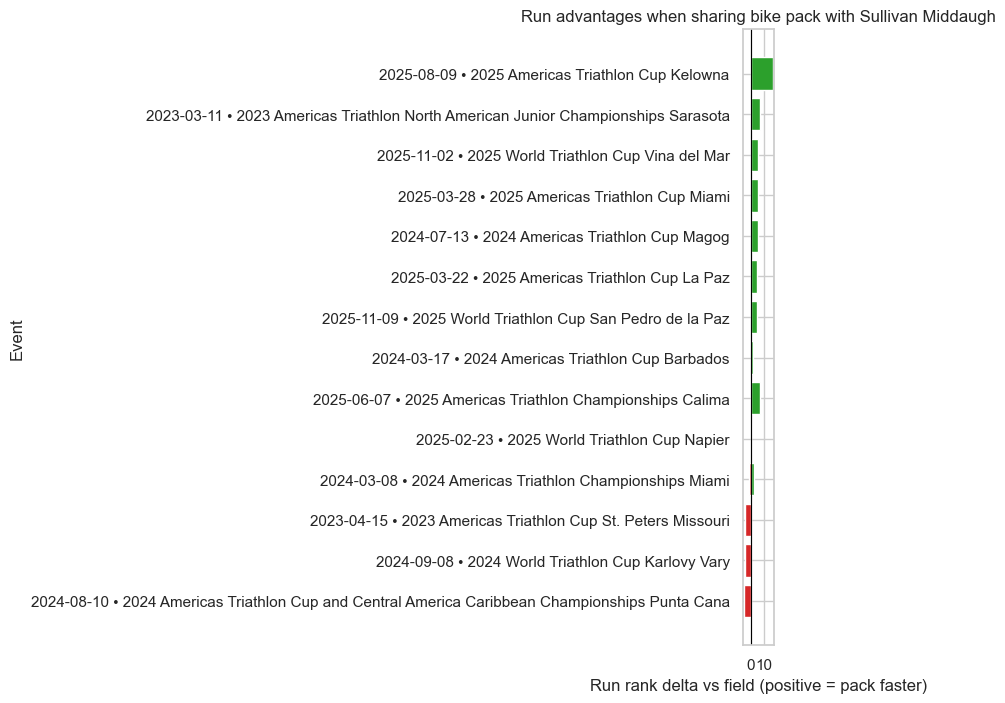

In [26]:
if case_studies.empty:
    print("Pack advantage viz skipped — no qualifying events to chart.")
else:
    plot_df = case_studies.sort_values("pack_run_advantage", ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45 * len(plot_df))))
    colors = np.where(plot_df["pack_run_advantage"] > 0, "#2ca02c", "#d62728")
    ax.barh(plot_df["event_label"], plot_df["pack_run_advantage"], color=colors)
    ax.set_xlabel("Run rank delta vs field (positive = pack faster)")
    ax.set_ylabel("Event")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Run advantages when sharing bike pack with {TARGET_SULLIVAN}")
    plt.tight_layout()
    plt.show()